In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from itertools import combinations

rng = np.random.default_rng(42)

# Physical constants
mu   = 0.04   # blood viscosity [dyne·s/cm²]
L    = 2.0    # vessel length [cm]
r_bar = 0.15  # mean radius [cm]

def sample_inputs(n, s_max, rng):
    """Draw n iid samples of (Q, r, xi) where xi is stenosis severity."""
    Q  = rng.normal(1.0,  0.2,  n)          # flow rate [mL/s]
    r  = rng.normal(0.15, 0.02, n)          # radius [cm]
    xi = rng.uniform(0.1, s_max, n)         # stenosis severity
    return Q, r, xi

def f1(Q, r, xi):
    """High-fidelity: Poiseuille + nonlinear stenosis loss."""
    A = np.pi * r**2
    K = 1.0 / (1.0 - xi)**4 - 1.0
    return 8*mu*L*Q / (np.pi * r**4) + K * Q**2 / (2 * A**2)

def f2(Q, r, xi):
    """Surrogate 1: Poiseuille only (ignores stenosis)."""
    return 8*mu*L*Q / (np.pi * r**4)

def f3(Q, r, xi):
    """Surrogate 2: Poiseuille with fixed mean radius."""
    return 8*mu*L*Q / (np.pi * r_bar**4)

def f4(Q, r, xi, noise_scale=0.5):
    """
    Surrogate 3: deliberately degraded model.
    Takes the f2 output and adds proportional Gaussian noise,
    making it cheap but only weakly correlated with f1.
    noise_scale controls how much noise is injected.
    """
    base = f2(Q, r, xi)
    noise = rng.normal(0, noise_scale * np.std(base), len(Q))
    return base + noise

# Evaluation costs (relative)
w_steno = np.array([1.0, 0.1, 0.001, 0.0001])

def estimate_stats(s_max, n_pilot=1000):
    """Estimate sigma1^2 and correlations rho_{1,i} via pilot samples."""
    Q, r, xi = sample_inputs(n_pilot, s_max, rng)
    y1 = f1(Q, r, xi)
    y2 = f2(Q, r, xi)
    y3 = f3(Q, r, xi)
    y4 = f4(Q, r, xi)
    sigma1_sq = np.var(y1, ddof=1)
    rho12 = np.corrcoef(y1, y2)[0, 1]
    rho13 = np.corrcoef(y1, y3)[0, 1]
    rho14 = np.corrcoef(y1, y4)[0, 1]
    return sigma1_sq, np.array([1.0, rho12, rho13, rho14])

# Quick check at s_max = 0.2
sig2, rhos = estimate_stats(0.2)
print(f'sigma1^2 = {sig2:.4e}')
print(f'rho = {rhos}')


sigma1^2 = 2.3785e+05
rho = [1.         0.99421184 0.32110096 0.89257865]


In [18]:
def mse_mc(p, sigma1_sq, w1):
    """Plain MC: MSE = sigma1^2 * w1 / p"""
    return sigma1_sq * w1 / p

def mse_mfmc(p, w_sub, rho_sub, sigma1_sq):
    """MFMC: MSE from Corollary 3.5"""
    rho_aug = np.append(rho_sub, 0)
    r_star  = np.sqrt(
        w_sub[0] * (rho_aug[:-1]**2 - rho_aug[1:]**2)
        / (w_sub * (1 - rho_sub[1]**2))
    )
    m1_star = p / (w_sub @ r_star)
    return sigma1_sq * (1 - rho_sub[1]**2) * p \
           / (m1_star**2 * w_sub[0])

def compute_gamma(w_sub, rho_sub):
    """Variance reduction ratio gamma"""
    rho_aug = np.append(rho_sub, 0)
    terms   = np.sqrt(w_sub/w_sub[0] *
                     (rho_aug[:-1]**2 - rho_aug[1:]**2))
    return terms.sum()**2

rho12   = 0.9947
gamma2  = 1.74e-01
speedup = 5.7x


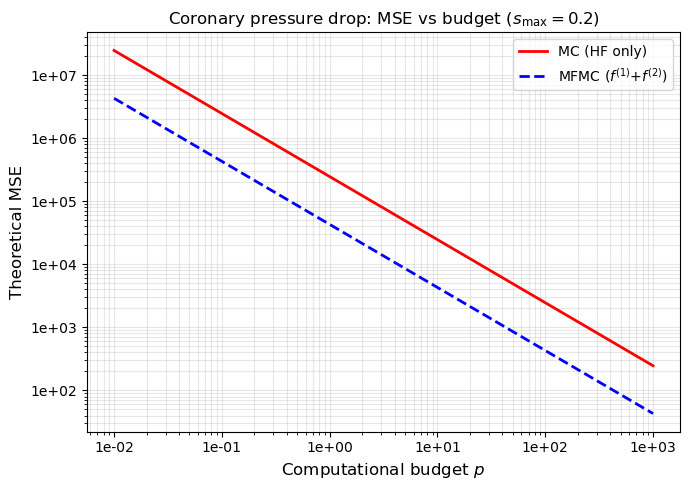


At s_max=0.5:
rho12   = 0.7467
gamma2  = 8.12e-01
speedup = 1.2x


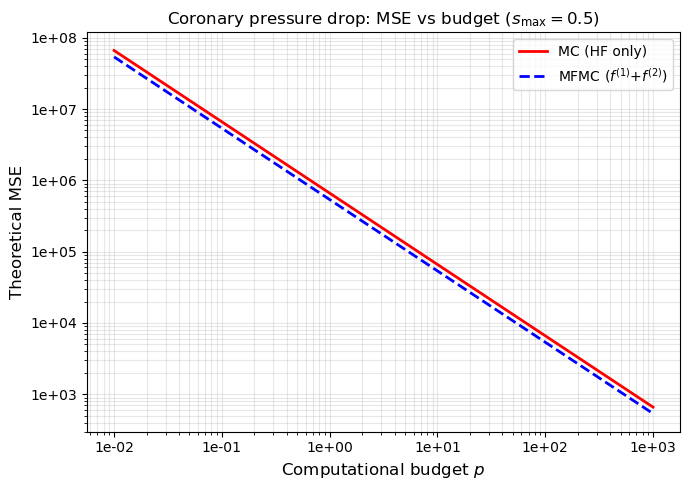

In [19]:
# ── Figure 4: s_max = 0.2 ──
s_max = 0.2
sigma1_sq, rhos = estimate_stats(s_max, n_pilot=1000)
rho12 = rhos[1]

# 只用两个模型 f1, f2
w_2mdl   = w_steno[[0, 1]]
rho_2mdl = np.array([1.0, rho12])

budgets = np.logspace(-2, 3, 200)

mse_hf   = np.array([mse_mc(p, sigma1_sq, w_steno[0])
                     for p in budgets])
mse_2mdl = np.array([mse_mfmc(p, w_2mdl, rho_2mdl, sigma1_sq)
                     for p in budgets])

gamma2 = compute_gamma(w_2mdl, rho_2mdl)
print(f'rho12   = {rho12:.4f}')
print(f'gamma2  = {gamma2:.2e}')
print(f'speedup = {1/gamma2:.1f}x')

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(budgets, mse_hf,   'r-',  lw=2,
          label='MC (HF only)')
ax.loglog(budgets, mse_2mdl, 'b--', lw=2,
          label=r'MFMC ($f^{(1)}$+$f^{(2)}$)')
ax.set_xlabel('Computational budget $p$', fontsize=12)
ax.set_ylabel('Theoretical MSE',          fontsize=12)
ax.set_title(r'Coronary pressure drop: MSE vs budget '
             r'($s_{\max}=0.2$)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))
plt.tight_layout()
plt.savefig('figA_smax02.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 5: s_max = 0.5 ──
s_max2 = 0.5
sigma1_sq2, rhos2 = estimate_stats(s_max2, n_pilot=1000)
rho12_2 = rhos2[1]

w_2mdl2   = w_steno[[0, 1]]
rho_2mdl2 = np.array([1.0, rho12_2])

mse_hf2   = np.array([mse_mc(p, sigma1_sq2, w_steno[0])
                      for p in budgets])
mse_2mdl2 = np.array([mse_mfmc(p, w_2mdl2, rho_2mdl2, sigma1_sq2)
                      for p in budgets])

gamma2_2 = compute_gamma(w_2mdl2, rho_2mdl2)
print(f'\nAt s_max=0.5:')
print(f'rho12   = {rho12_2:.4f}')
print(f'gamma2  = {gamma2_2:.2e}')
print(f'speedup = {1/gamma2_2:.1f}x')

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(budgets, mse_hf2,   'r-',  lw=2,
          label='MC (HF only)')
ax.loglog(budgets, mse_2mdl2, 'b--', lw=2,
          label=r'MFMC ($f^{(1)}$+$f^{(2)}$)')
ax.set_xlabel('Computational budget $p$', fontsize=12)
ax.set_ylabel('Theoretical MSE',          fontsize=12)
ax.set_title(r'Coronary pressure drop: MSE vs budget '
             r'($s_{\max}=0.5$)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))
plt.tight_layout()
plt.savefig('figA_smax05.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
def draw_samples(n, s_max=0.5):
    np.random.seed(42)
    Q = np.random.normal(1.0,  0.2,  n)
    r = np.random.normal(0.15, 0.02, n)
    s = np.random.uniform(0.1, s_max, n)
    return Q, r, s

In [12]:
def estimate_statistics(n_pilot=500, s_max=0.5):
    Q, r, s   = draw_samples(n_pilot, s_max)
    y1        = f1(Q, r, s)
    y2        = f2(Q, r, s)
    y3        = f3(Q, r, s)
    sigma1_sq = np.var(y1, ddof=1)
    rho12     = np.corrcoef(y1, y2)[0, 1]
    rho13     = np.corrcoef(y1, y3)[0, 1]
    return sigma1_sq, rho12, rho13

In [13]:
def compute_gamma(w_sub, rho_sub):
    rho_aug = np.append(rho_sub, 0)
    terms   = np.sqrt(w_sub/w_sub[0] *
                     (rho_aug[:-1]**2 - rho_aug[1:]**2))
    return terms.sum()**2
w = np.array([1.0, 0.1, 0.001])

In [14]:
s_max     = 0.2
sigma1_sq, rho12, rho13 = estimate_statistics(500, s_max)
rho       = np.array([1.0, rho12, rho13])


print(f'sigma1_sq = {sigma1_sq:.6f}')
print(f'rho12     = {rho12:.6f}')
print(f'rho13     = {rho13:.6f}')
print()
print(f'gamma (2 models): {compute_gamma(w[:2], rho[:2]):.2e}')
print(f'gamma (3 models): {compute_gamma(w,     rho):.2e}')

sigma1_sq = 167609.346623
rho12     = 0.992920
rho13     = 0.882797

gamma (2 models): 1.87e-01
gamma (3 models): 8.43e-02


In [49]:
def mse_mc(p,sigma1_sq,w1):
    return sigma1_sq * w1/p
def mse_mfmc(p, w_sub, rho_sub, sigma1_sq):
    """
    MFMC: MSE from Corollary 3.5 eq.(3.19)
    MSE = sigma1^2 / p * (sum sqrt(wi*(rho_i^2-rho_{i+1}^2)))^2
    """
    rho_aug = np.append(rho_sub, 0)
    # r_i* from eq.(3.14)
    r_star = np.sqrt(
        w_sub[0] * (rho_aug[:-1]**2 - rho_aug[1:]**2)
        / (w_sub * (1 - rho_sub[1]**2))
    )
    m1_star = p / (w_sub @ r_star)
    # MSE from eq.(3.19)
    return sigma1_sq * (1 - rho_sub[1]**2) * p \
           / (m1_star**2 * w_sub[0])

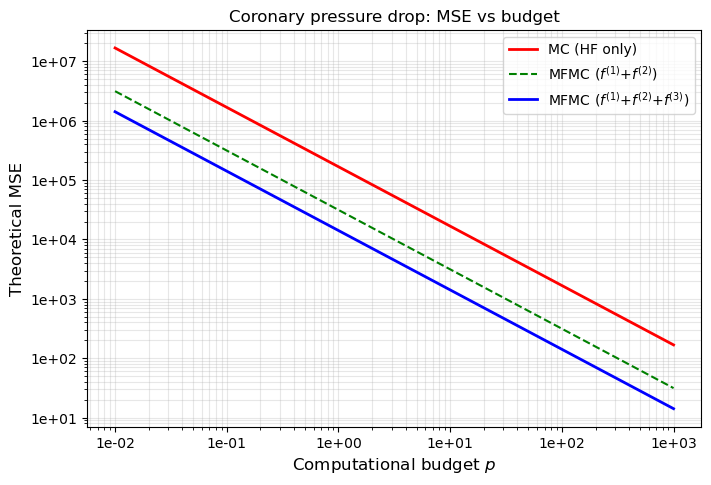

gamma_2 = 1.87e-01
gamma_3 = 8.43e-02
speedup (2 models) = 5.3x
speedup (3 models) = 11.9x


In [ ]:


s_max     = 0.2
sigma1_sq, rho12, rho13 = estimate_statistics(500, s_max)
rho       = np.array([1.0, rho12, rho13])

budgets  = np.logspace(-2, 3, 200)


mse_hf   = np.array([mse_mc(p, sigma1_sq, w[0])
                     for p in budgets])
mse_2mdl = np.array([mse_mfmc(p, w[:2], rho[:2], sigma1_sq)
                     for p in budgets])
mse_3mdl = np.array([mse_mfmc(p, w,     rho,     sigma1_sq)
                     for p in budgets])


fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(budgets, mse_hf,   'r-',  lw=2,
          label='MC (HF only)')
ax.loglog(budgets, mse_2mdl, 'g--', lw=1.5,
          label=r'MFMC ($f^{(1)}$+$f^{(2)}$)')
ax.loglog(budgets, mse_3mdl, 'b-',  lw=2,
          label=r'MFMC ($f^{(1)}$+$f^{(2)}$+$f^{(3)}$)')

ax.set_xlabel('Computational budget $p$', fontsize=12)
ax.set_ylabel('Theoretical MSE',          fontsize=12)
ax.set_title('Coronary pressure drop: MSE vs budget',
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x:.0e}'))
plt.show()


print(f'gamma_2 = {compute_gamma(w[:2], rho[:2]):.2e}')
print(f'gamma_3 = {compute_gamma(w,     rho):.2e}')
print(f'speedup (2 models) = {1/compute_gamma(w[:2], rho[:2]):.1f}x')
print(f'speedup (3 models) = {1/compute_gamma(w,     rho):.1f}x')